In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm

from scipy.linalg import block_diag
from collections import deque

import kind
import ex_duffing
import util_data
import util_nn
import reinforcement_learning as rl

In [2]:
# --! define a reward function --!

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 1.0 * np.eye(action_ndim)

dt=2e-2
setpoint = [1.0, 0.0]

reward_fn_nom = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=1.0, lambda_E=0.05)
reward_fn_exc = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=20.0, lambda_E=0.1)

In [3]:
# --! make real simulation environments for a Duffing oscillator --!

duffing_nom = ex_duffing.duffing_adapter(ex_duffing.make_duffing('nom', reward_fn_nom, dt=dt))
duffing_exc = ex_duffing.duffing_adapter(ex_duffing.make_duffing('exc', reward_fn_exc, dt=dt))

In [4]:
# --! make a base policy --!

base_policy = ex_duffing.make_base_policy(
    duffing_nom.env.alpha, duffing_nom.env.delta,
    q=state_cost, r=action_cost,
    dt=dt,
    setpoint=setpoint)


In [5]:
# --! load a trained KIND model --!

# --! specify KIND arguments used when training the model
parser = kind.create_args_parser()
args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '3848',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.6',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '64',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

# --! instantiate a KIND model
model = kind.model(args)

# --! load trained weights into the model
model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# --! create a dataset
dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size,
    (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=False) # <-- dataset is not normalized

model = kind.model_adapter(model, dataset.normalizer)

In [6]:
train_loader, _, _ = dataset.load(data_type='nom')
zeta = []

with torch.no_grad():
    for back, fore in train_loader:

        model_output = model(back)
        zeta_nom = model_output[14]

        zeta.append(torch.mean(zeta_nom).item())

print(f'average zeta on nominal data is {np.mean(zeta)}')

train_loader, _, _ = dataset.load(data_type='exc')
zeta = []

with torch.no_grad():
    for back, fore in train_loader:

        model_output = model(back)
        zeta_nom = model_output[14]

        zeta.append(torch.mean(zeta_nom).item())

print(f'average zeta on excursion data is {np.mean(zeta)}')

#print(tata.shape)

average zeta on nominal data is 0.0005416665113561096
average zeta on excursion data is 0.45599858607015303


In [7]:
factory = ex_duffing.replay_factory()

nsample = args.lookback_nsample

replay_nom = factory.create(duffing_nom, rl.policies(base_policy, None), 0.0, nsample, 3*nsample)
replay_exc = factory.create(duffing_exc, rl.policies(base_policy, None), 0.0, nsample, 3*nsample)

replay_mixed = replay_nom + replay_exc

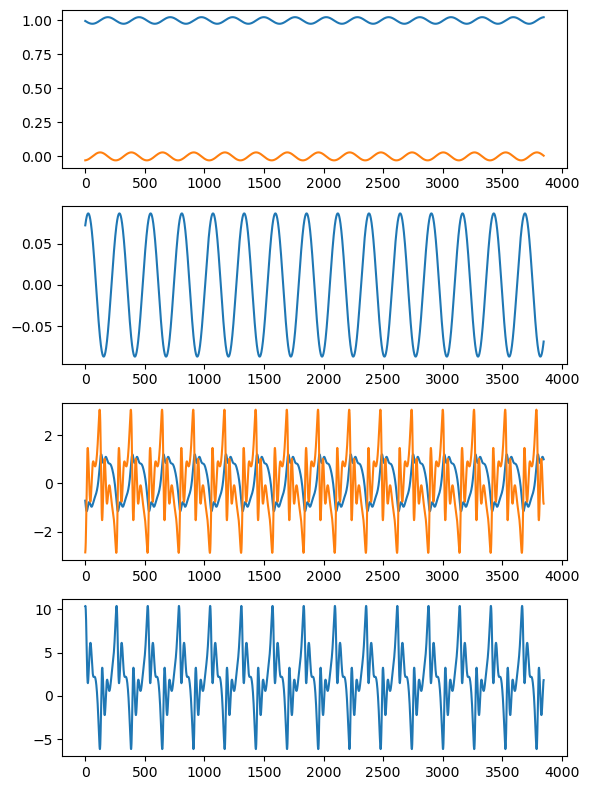

tensor([[[0.9997]]])
tensor([[[1.4357]]])


In [8]:
state, reward, next_state, done = map(torch.cat, zip(*replay_nom.buffer))
state_nom = factory.extract_current_s(state)
action_nom = factory.extract_current_a(state)

state, reward, next_state, done = map(torch.cat, zip(*replay_exc.buffer))
state_exc = factory.extract_current_s(state)
action_exc = factory.extract_current_a(state)

with torch.no_grad():
    plt.figure(figsize=(6,8))

    plt.subplot(4,1,1)
    plt.plot(state_nom[:, 0, :2])

    plt.subplot(4,1,2)
    plt.plot(action_nom[:, 0, :])

    plt.subplot(4,1,3)
    plt.plot(state_exc[:, 0, :2])

    plt.subplot(4,1,4)
    plt.plot(action_exc[:, 0, :])

    plt.tight_layout()
    plt.show()

state_nom_norm = torch.mean(torch.linalg.norm(state_nom, dim=-1, keepdim=True), dim=0, keepdim=True)
print(state_nom_norm)

state_exc_norm = torch.mean(torch.linalg.norm(state_exc, dim=-1, keepdim=True), dim=0, keepdim=True)
print(state_exc_norm)

#print(tata.shape)

In [9]:
#reward_fn_nom = ex_duffing.DuffingRewardTorch(state_cost, action_cost, setpoint, beta=1.0, lambda_E=0.05)
#reward_fn_exc = ex_duffing.DuffingRewardTorch(state_cost, action_cost, setpoint, beta=20.0, lambda_E=0.1)

pi = rl.policy_iteration(base_policy, kind.regimes(duffing_nom.reward_fn, duffing_exc.reward_fn), dataset.normalizer)
loss_nom, loss_exc = pi.evaluate_policy(factory, kind.regimes(replay_nom, replay_exc))


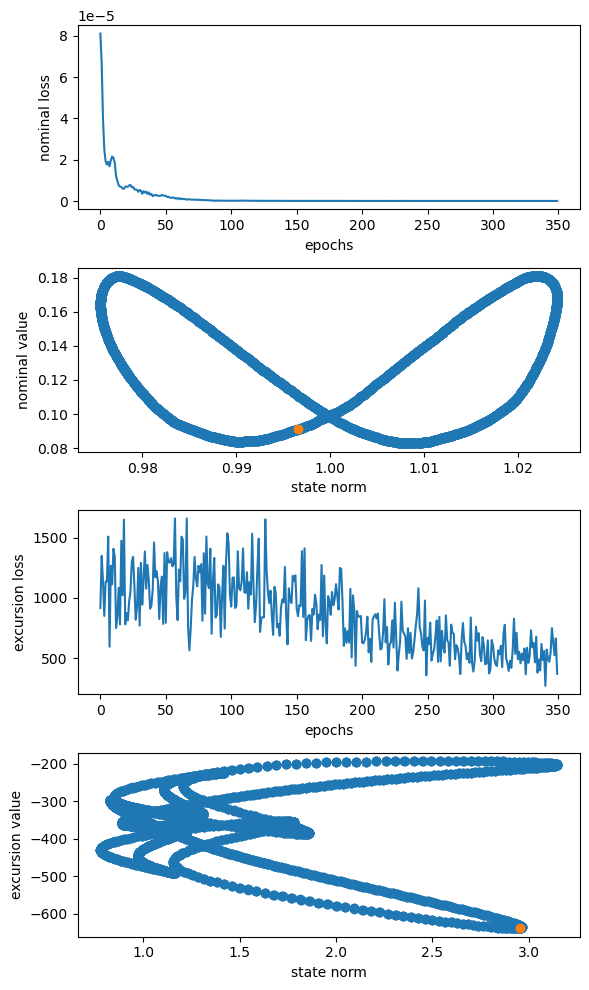

In [10]:

pi.value_fn_nom.eval()
pi.value_fn_exc.eval()

state, reward, next_state, done = map(torch.cat, zip(*replay_nom.buffer))
obs_nom = factory.extract_current_s(state)
obs_norm_nom = torch.squeeze(torch.linalg.norm(obs_nom, dim=-1, ord=2))
value_nom = torch.squeeze(pi.value_fn_nom(obs_nom))

state, reward, next_state, done = map(torch.cat, zip(*replay_exc.buffer))
obs_exc = factory.extract_current_s(state)
obs_norm_exc = torch.squeeze(torch.linalg.norm(obs_exc, dim=-1, ord=2))
value_exc = torch.squeeze(pi.value_fn_exc(obs_exc))

with torch.no_grad():

    plt.figure(figsize=(6,10))

    plt.subplot(4,1,1)
    plt.plot(loss_nom)
    plt.xlabel('epochs')
    plt.ylabel('nominal loss')

    plt.subplot(4,1,2)
    plt.scatter(obs_norm_nom, value_nom)
    plt.scatter(obs_norm_nom[0], value_nom[0])
    plt.xlabel('state norm')
    plt.ylabel('nominal value')

    plt.subplot(4,1,3)
    plt.plot(loss_exc)
    plt.xlabel('epochs')
    plt.ylabel('excursion loss')

    plt.subplot(4,1,4)
    plt.scatter(obs_norm_exc, value_exc)
    plt.scatter(obs_norm_exc[0], value_exc[0])
    plt.xlabel('state norm')
    plt.ylabel('excursion value')

    plt.tight_layout()
    plt.show()

#print(tata.shape)

In [11]:
loss = pi.improve_policy(model, factory, kind.regimes(replay_nom, replay_exc))

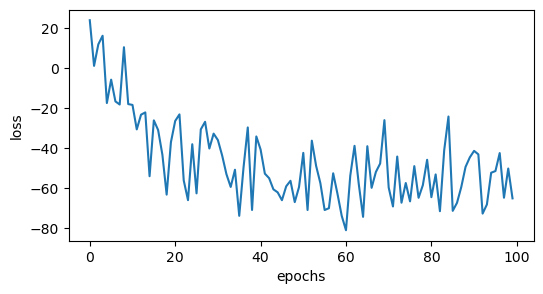

In [12]:
with torch.no_grad():

    plt.figure(figsize=(6,3))

    plt.plot(loss)
    plt.xlabel('epochs')
    plt.ylabel('loss')

    plt.show()


In [13]:
pi.residual_policy.eval()

with torch.no_grad():
    replay_nom2 = factory.create(duffing_nom, rl.policies(base_policy, pi.residual_policy), torch.tensor(0.0006), nsample, 3*nsample)
    replay_exc2 = factory.create(duffing_exc, rl.policies(base_policy, pi.residual_policy), torch.tensor(0.46), nsample, 3*nsample)

In [14]:
replay_data_nom = map(torch.cat, zip(*replay_nom2.buffer))
replay_data_exc = map(torch.cat, zip(*replay_exc2.buffer))

pi.value_fn_nom.eval()
pi.value_fn_exc.eval()
pi.residual_policy.eval()

horizon = 200
gamma = 0.94

with torch.no_grad():
    a_nom = rl.advantage(
        model,
        rl.policies(pi.base_policy, pi.residual_policy),
        pi.reward_fn,
        rl.value_functions(pi.value_fn_nom, pi.value_fn_exc),
        dataset.normalizer,
        factory, replay_data_nom,
        horizon, gamma
    )

    a_exc = rl.advantage(
        model,
        rl.policies(pi.base_policy, pi.residual_policy),
        pi.reward_fn,
        rl.value_functions(pi.value_fn_nom, pi.value_fn_exc),
        dataset.normalizer,
        factory, replay_data_exc,
        horizon, gamma
    )


tensor([[[0.9997]]])
tensor([[[0.9997]]])
tensor([[[1.4357]]])
tensor([[[1.5204]]])


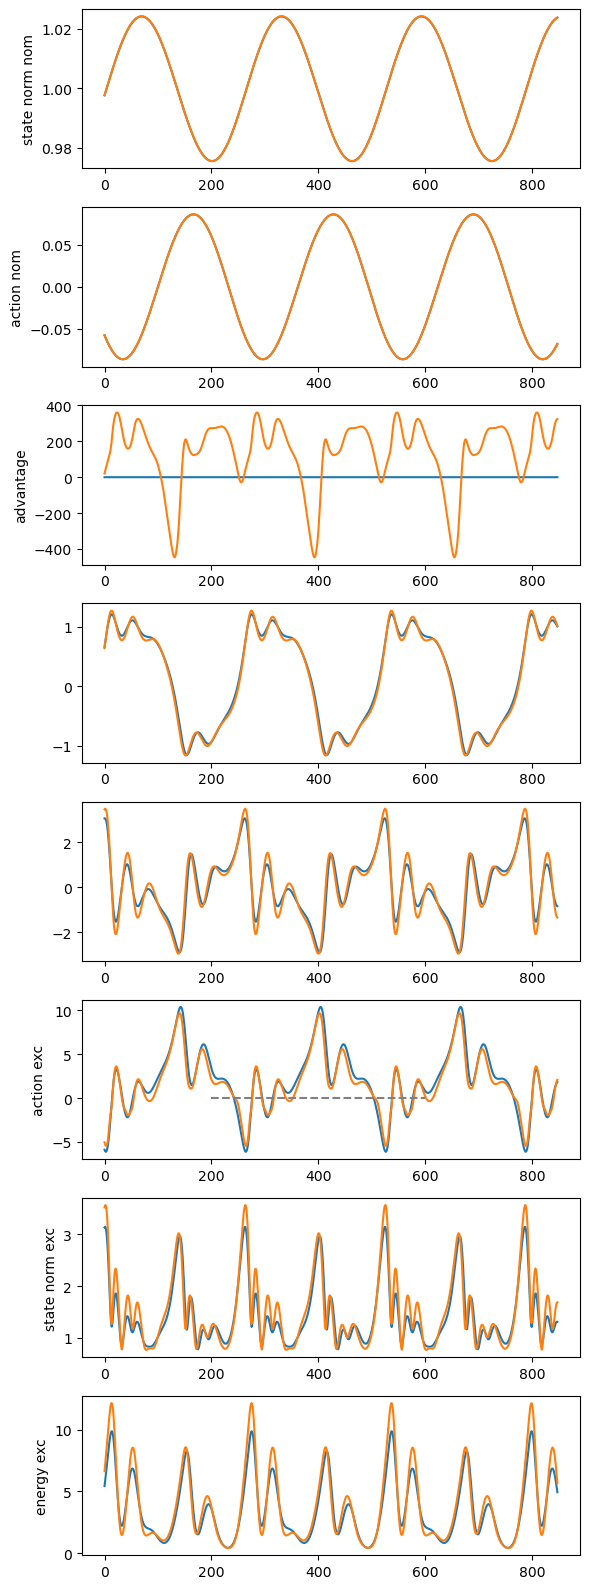

In [17]:
lookback, reward, next_lookback, done = map(torch.cat, zip(*replay_nom.buffer))
state_nom1 = factory.extract_current_s(lookback)
action_nom1 = factory.extract_current_a(lookback)

state_norm_nom1 = torch.linalg.norm(state_nom1, dim=-1, keepdim=True)
print(torch.mean(state_norm_nom1, dim=0, keepdim=True))

lookback, reward, next_lookback, done = map(torch.cat, zip(*replay_nom2.buffer))
state_nom2 = factory.extract_current_s(lookback)
action_nom2 = factory.extract_current_a(lookback)

state_norm_nom2 = torch.linalg.norm(state_nom2, dim=-1, keepdim=True)
print(torch.mean(state_norm_nom2, dim=0, keepdim=True))

lookback, reward, next_lookback, done = map(torch.cat, zip(*replay_exc.buffer))
state_exc1 = factory.extract_current_s(lookback)
action_exc1 = factory.extract_current_a(lookback)

state_norm_exc1 = torch.linalg.norm(state_exc1, dim=-1, keepdim=True)
print(torch.mean(state_norm_exc1, dim=0, keepdim=True))
state_energy_exc1 = ex_duffing.duffing_energy_torch(state_exc1, alpha=-1.0, beta=20.0)

lookback, reward, next_lookback, done = map(torch.cat, zip(*replay_exc2.buffer))
state_exc2 = factory.extract_current_s(lookback)
action_exc2 = factory.extract_current_a(lookback)

state_norm_exc2 = torch.linalg.norm(state_exc2, dim=-1, keepdim=True)
print(torch.mean(state_norm_exc2, dim=0, keepdim=True))
state_energy_exc2 = ex_duffing.duffing_energy_torch(state_exc2, alpha=-1.0, beta=20.0)

datasaved = True

with torch.no_grad():
    step = torch.arange(a_nom.shape[0]).reshape(-1, 1)

    plt.figure(figsize=(6,16))

    plt.subplot(8,1,1)
    plt.plot(state_norm_nom1[3000:, 0, 0])
    plt.plot(state_norm_nom2[3000:, 0, 0])
    plt.ylabel('state norm nom')

    plt.subplot(8,1,2)
    plt.plot(action_nom1[3000:, 0, 0])
    plt.plot(action_nom2[3000:, 0, 0])
    plt.ylabel('action nom')

    plt.subplot(8,1,3)
    plt.plot(a_nom[3000:, 0, 0])
    plt.plot(a_exc[3000:, 0, 0])
    plt.ylabel('advantage')

    plt.subplot(8,1,4)
    plt.plot(state_exc[3000:, 0, 0])
    plt.plot(state_exc2[3000:, 0, 0])

    plt.subplot(8,1,5)
    plt.plot(state_exc[3000:, 0, 1])
    plt.plot(state_exc2[3000:, 0, 1])

    plt.subplot(8,1,6)
    plt.plot(action_exc1[3000:, 0, 0])
    plt.plot(action_exc2[3000:, 0, 0])
    plt.plot([200, 600], [0, 0], linestyle='dashed', color='gray')
    plt.ylabel('action exc')

    plt.subplot(8,1,7)
    plt.plot(state_norm_exc1[3000:, 0, 0])
    plt.plot(state_norm_exc2[3000:, 0, 0])
    plt.ylabel('state norm exc')

    plt.subplot(8,1,8)
    plt.plot(state_energy_exc1[3000:, 0, 0])
    plt.plot(state_energy_exc2[3000:, 0, 0])
    plt.ylabel('energy exc')

    plt.tight_layout()
    plt.show()

    if datasaved:
        step = step[3000:, :1] - 3000
        savedata = np.expand_dims(np.concatenate([
            step,
            a_exc[3000:, :1, 0],
            state_exc[3000:, :1, 0], state_exc[3000:, :1, 1]], axis=1), 0)
        util_data.write_datafile(f'../../savedata/dreamer/advantage_epoch_100_h_200', savedata, delim=' ')


In [18]:
torch.save(pi.residual_policy.state_dict(), '../../models/dreamer' + '/' + 'policy_checkpoint.pth')